# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned stock market dataset and understand the historical behavior of Apple's stock through statistical summaries and visualizations.

### Analysis Performed

- Dataset Overview
- Statistical Summary
- Closing Price Trend
- Trading Volume Trend
- Price Distribution
- Outlier Detection
- Correlation Analysis

In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# all plots shown inside of the notebook
%matplotlib inline  

In [20]:
apple = pd.read_csv("../data/cleaned/AAPL_clean.csv")

apple["Date"] = pd.to_datetime(apple["Date"])

apple.head()

,Date,Close,High,Low,Open,Volume,Company
0,2015-01-02,24.192610,24.659512,23.754473,24.648447,212818400,AAPL
1,2015-01-05,23.511055,24.042129,23.325180,23.962467,257142000,AAPL
2,2015-01-06,23.513266,23.772163,23.152577,23.575224,263188400,AAPL
3,2015-01-07,23.842985,23.942561,23.610640,23.721280,160423600,AAPL
4,2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000,AAPL


In [22]:
print("Shape :", apple.shape)

Shape : (2765, 7)


In [21]:
apple.info()

<class 'pandas.DataFrame'>
RangeIndex: 2765 entries, 0 to 2764
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2765 non-null   datetime64[us]
 1   Close    2765 non-null   float64       
 2   High     2765 non-null   float64       
 3   Low      2765 non-null   float64       
 4   Open     2765 non-null   float64       
 5   Volume   2765 non-null   int64         
 6   Company  2765 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 151.3 KB


In [23]:
apple.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2765,2020-06-29 19:22:56.202531,2015-01-02 00:00:00,2017-09-29 00:00:00,2020-06-30 00:00:00,2023-03-29 00:00:00,2025-12-30 00:00:00,NaN
Close,2765.0,106.067728,20.565865,36.580727,88.302399,168.319778,285.659271,74.130174
High,2765.0,107.119518,20.868638,36.985185,89.268189,169.717637,288.084759,74.836666
Low,2765.0,104.911608,20.367811,36.239433,87.140528,166.816741,282.774617,73.343359
Open,2765.0,105.970905,20.488463,36.58657,88.207968,168.054575,285.669263,74.050475
Volume,2765.0,111429771.066908,17910600.0,64902300.0,94550000.0,137298000.0,648825200.0,68035920.907984


## Observation

- The dataset contains daily historical stock prices.
- There are no missing values.
- Numerical columns are ready for analysis.

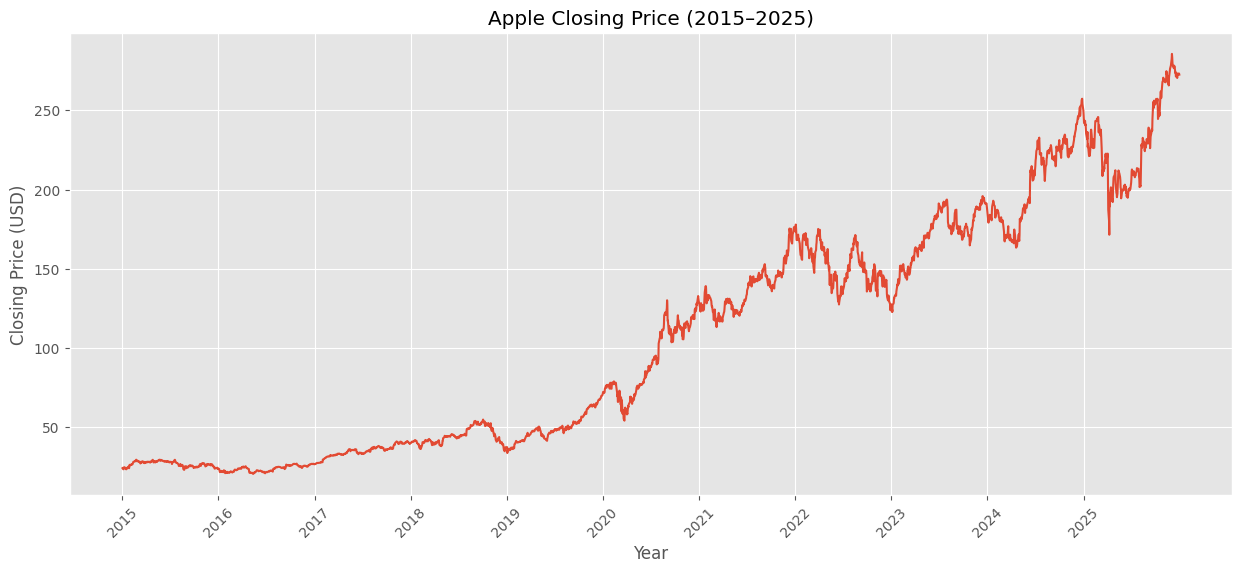

In [ ]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x="Date",
    y="Close",
    data=apple
)

plt.title("Apple Closing Price (2015–2025)")

plt.xlabel("Year")

years = apple["Date"].dt.year.unique()

plt.xticks(
    pd.to_datetime(years.astype(str) + "-01-01"),
    years,
    rotation=45
)

plt.ylabel("Closing Price (USD)")

plt.show()

### Observation

Apple's closing price shows a strong upward trend over the years with noticeable declines during major market corrections, followed by significant recovery.

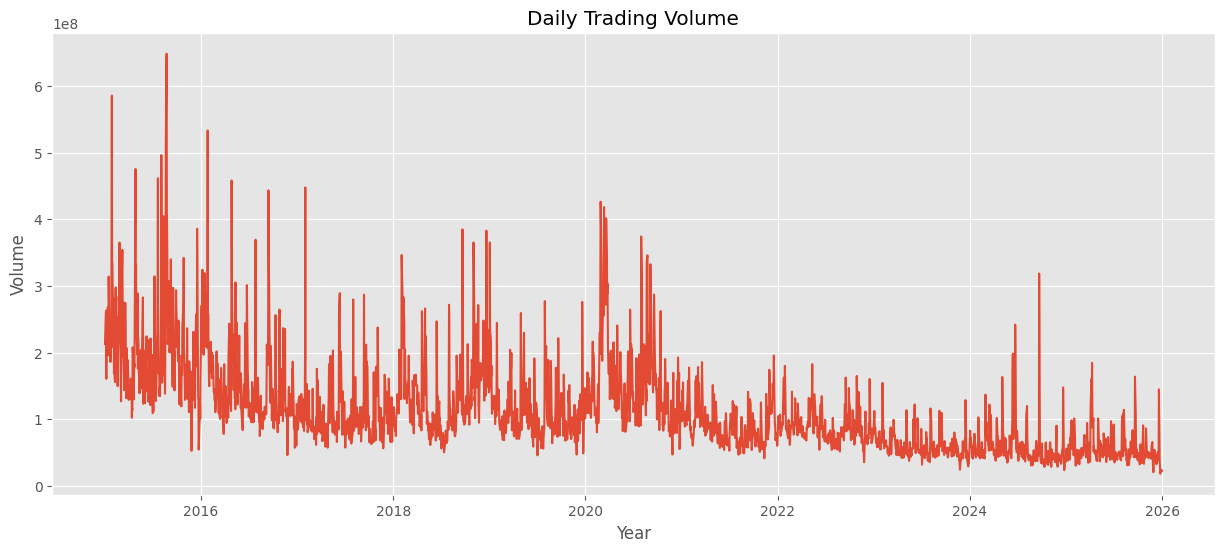

In [37]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x="Date",
    y="Volume",
    data=apple
)

plt.title("Daily Trading Volume")

plt.xlabel("Year")

plt.ylabel("Volume")

plt.show()

### Observation

Trading volume spikes indicate periods of increased investor activity, often corresponding to important market events.

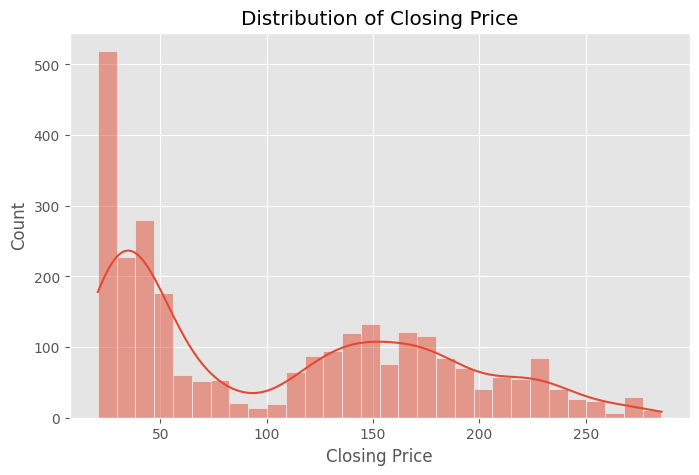

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    apple["Close"],
    bins=30,
    kde=True
)

plt.title("Distribution of Closing Price")

plt.xlabel("Closing Price")

plt.show()

### Observation

The distribution is positively skewed because Apple's stock price increased substantially over the selected time period.

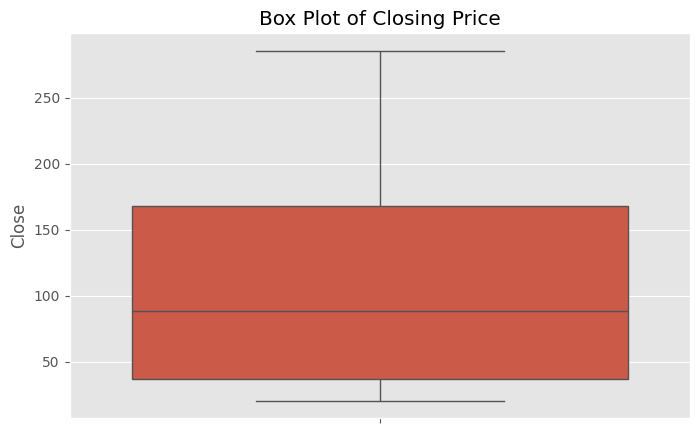

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=apple["Close"]
)

plt.title("Box Plot of Closing Price")

plt.show()

In [43]:
Q0 = apple["Close"].min()
Q1 = apple["Close"].quantile(0.25)
Q2 = apple["Close"].median()          # or quantile(0.50)
Q3 = apple["Close"].quantile(0.75)
Q4 = apple["Close"].max()

IQR = Q3 - Q1

print(f"Q0 (Minimum): {Q0:.2f}")
print(f"Q1 (25th Percentile): {Q1:.2f}")
print(f"Q2 (Median): {Q2:.2f}")
print(f"Q3 (75th Percentile): {Q3:.2f}")
print(f"Q4 (Maximum): {Q4:.2f}")
print(f"IQR: {IQR:.2f}")

Q0 (Minimum): 20.57
Q1 (25th Percentile): 36.58
Q2 (Median): 88.30
Q3 (75th Percentile): 168.32
Q4 (Maximum): 285.66
IQR: 131.74


### Observation

The box plot shows several high-value observations. These represent genuine market growth rather than data errors.

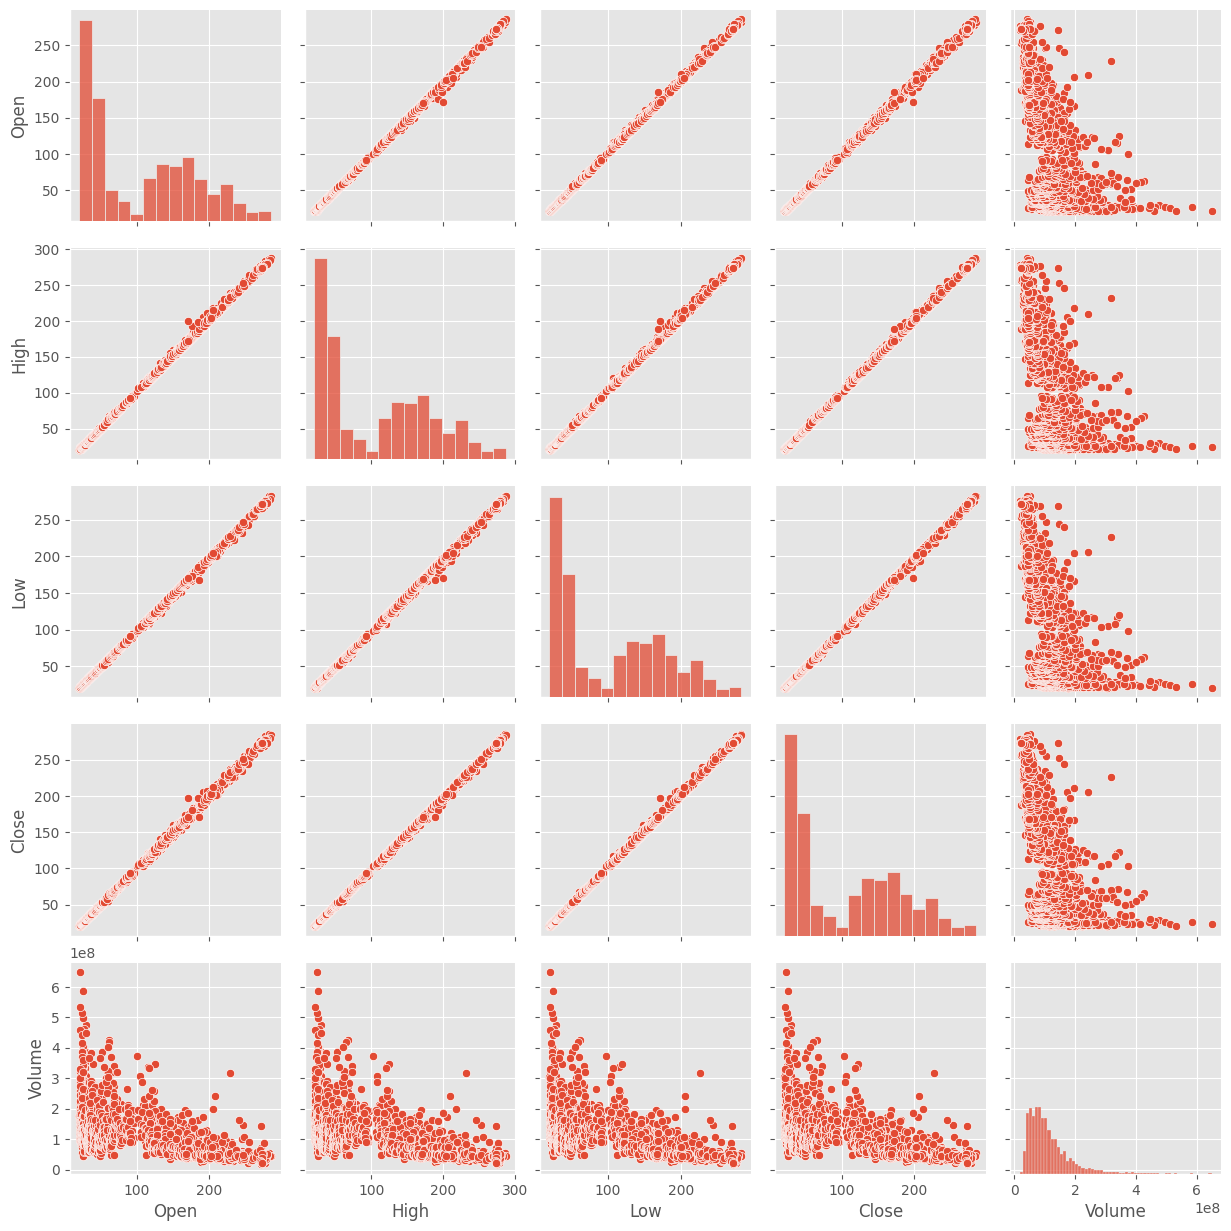

In [45]:
sns.pairplot(
    apple[
        ["Open","High","Low","Close","Volume"]
    ]
)

plt.show()

### Pair Plot Analysis

- The pair plot shows relationships among Open, High, Low, Close, and Volume.
- Open, High, Low, and Close exhibit a very strong positive linear relationship, indicating that these stock price variables move together.
- Histograms on the diagonal reveal that all price variables are right-skewed, with most observations at lower price levels and fewer observations at higher prices.
- Trading Volume has a highly right-skewed distribution, showing that most trading days have moderate volume while a few days experience exceptionally high trading activity.
- Scatter plots involving Volume display a weak to moderate negative relationship with stock prices, suggesting that higher stock prices are generally associated with lower trading volumes.
- Overall, the pair plot indicates strong positive correlations among all price-related variables and a comparatively weaker relationship between price and trading volume.

## Conclusion

The exploratory analysis reveals that Apple's stock experienced significant long-term growth during the selected period. Price-related variables are highly correlated, while trading volume behaves independently during many periods. The dataset is now well understood and ready for feature engineering and advanced financial analysis.